In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/Users/amogh/Machine Learning Projects/Salary Data.csv")
df.head(5)

,Age,Gender,Education Level,Job Title,Years of Experience,Salary
0,32.0,Male,Bachelor's,Software Engineer,5.0,90000.0
1,28.0,Female,Master's,Data Analyst,3.0,65000.0
2,45.0,Male,PhD,Senior Manager,15.0,150000.0
3,36.0,Female,Bachelor's,Sales Associate,7.0,60000.0
4,52.0,Male,Master's,Director,20.0,200000.0


In [5]:
df.shape

(375, 6)

In [7]:
df = df.dropna()
df.shape

(373, 6)

In [8]:
xtrain = df['Years of Experience'].values
ytrain = df['Salary'].values

In [9]:
print(xtrain, ytrain)

[ 5.   3.  15.   7.  20.   2.  12.   4.   1.  10.   3.  18.   6.  14.
  2.  16.   7.  12.   0.  22.   5.  19.   2.   9.  13.   3.  11.   1.
 15.   6.  25.   4.   3.  10.  20.   2.   7.  14.   1.  21.   5.  18.
  3.   8.  13.   2.   5.  16.  11.   0.  22.   7.  12.  19.   3.   9.
  2.  17.   4.   7.  23.   3.  12.  21.   1.  10.  19.   5.   8.  18.
  6.  11.  16.   2.  14.  10.  22.   6.  20.   3.   8.  13.   0.  24.
  2.  10.   2.  15.  21.   6.  11.   3.  18.  25.   7.  12.  22.   1.
 10.  20.   5.   8.  19.   5.  13.  16.   3.   7.  14.   2.  15.   9.
 22.   6.   0.5  6.  15.  20.   3.  10.  17.  25.   5.  11.  16.   2.
  9.  18.   4.   8.  21.   3.  12.  22.   1.  10.  19.   4.   7.  14.
  2.  13.   5.  20.   1.5  8.  16.   4.  10.  19.   3.  11.  18.   2.
  9.  14.   5.   7.  23.   2.  12.  21.   3.   7.  13.   1.5 14.  18.
  4.   9.  20.   2.  16.   1.5  7.  18.   4.  10.  20.   2.   9.  15.
  2.   8.  14.   6.   9.  22.   1.5 12.  19.   3.   7.  13.   2.  11.
 17.   5.   9.  21. 

In [10]:
xtrain = (xtrain - xtrain.mean()) / xtrain.std()
ytrain = (ytrain - ytrain.mean()) / ytrain.std()

In [11]:
print(df.isnull().sum())
print(np.isnan(xtrain).any(), np.isnan(ytrain).any())

Age                    0
Gender                 0
Education Level        0
Job Title              0
Years of Experience    0
Salary                 0
dtype: int64
False False


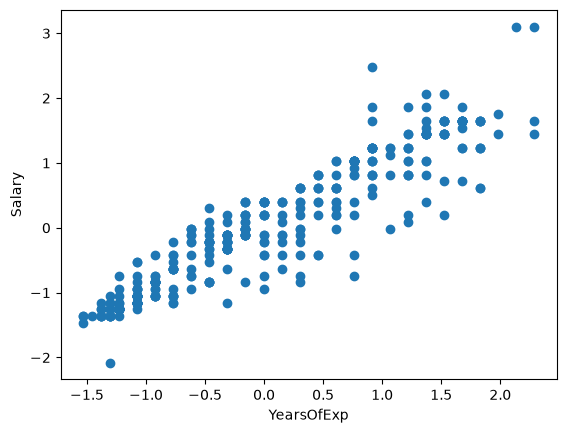

In [12]:
plt.scatter(xtrain, ytrain)
plt.xlabel("YearsOfExp")
plt.ylabel("Salary")
plt.show()

In [13]:
def cost_function(xval, yval, wval, bval):
    m = len(xval)
    cost_sum = 0

    for i in range(m):
        fun = wval * xval[i] + bval
        
        cost = (fun - yval[i]) ** 2
        cost_sum += cost

        total_cost = (1/(2*m)) * cost_sum
    return total_cost

In [14]:
def gradient_function(xval, yval, wval, bval):
    m = len(xval)
    dc_dw = 0
    dc_db = 0
    
    for i in range(m):
        fun = wval * xval[i] + bval

        dc_dw += (fun - yval[i]) * xval[i]
        dc_db += (fun - yval[i])

    dc_dw = (1/m) * dc_dw
    dc_db = (1/m) * dc_db

    return dc_dw, dc_db

In [15]:
def gradient_descent(xval, yval, alpha, iterations):
    wval = 0
    bval = 0

    for i in range(iterations):
        dc_dw, dc_db = gradient_function(xval, yval, wval, bval)

        wval = wval - alpha * dc_dw
        bval = bval - alpha * dc_db

        print(f"Iterations {i}: , Cost:{cost_function(xval, yval, wval, bval)}")
    return wval, bval

In [16]:
learning_rate = 0.3
iterations = 1000

final_w, final_b = gradient_descent(xval = xtrain, yval = ytrain, alpha = learning_rate, iterations = iterations)
print(f'w: {final_w:.4f}, b: {final_b:.4f}')

Iterations 0: , Cost:0.27929028900961195
Iterations 1: , Cost:0.17114253062432233
Iterations 2: , Cost:0.11815012901553015
Iterations 3: , Cost:0.09218385222722213
Iterations 4: , Cost:0.0794603766009513
Iterations 5: , Cost:0.07322587354407849
Iterations 6: , Cost:0.07017096704621102
Iterations 7: , Cost:0.0686740628622556
Iterations 8: , Cost:0.06794057981211776
Iterations 9: , Cost:0.06758117311755005
Iterations 10: , Cost:0.06740506383721184
Iterations 11: , Cost:0.06731877028984615
Iterations 12: , Cost:0.06727648645163715
Iterations 13: , Cost:0.06725576737091438
Iterations 14: , Cost:0.06724561502136045
Iterations 15: , Cost:0.0672406403700789
Iterations 16: , Cost:0.06723820279095112
Iterations 17: , Cost:0.06723700837717839
Iterations 18: , Cost:0.06723642311442962
Iterations 19: , Cost:0.0672361363356829
Iterations 20: , Cost:0.06723599581409705
Iterations 21: , Cost:0.06723592695851988
Iterations 22: , Cost:0.06723589321928729
Iterations 23: , Cost:0.06723587668706292
Iterat

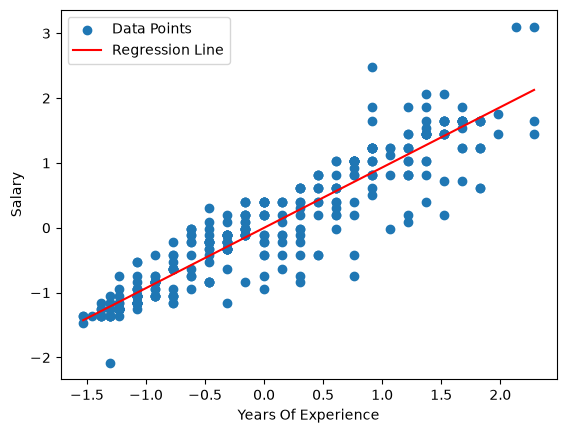

In [17]:
plt.scatter(xtrain, ytrain, label = "Data Points")

x_vals = np.linspace(min(xtrain), max(xtrain), 100)
y_vals = final_w * x_vals + final_b
plt.plot(x_vals, y_vals, color = "red", label = "Regression Line")

plt.xlabel("Years Of Experience")
plt.ylabel("Salary")
plt.legend()
plt.show()